## PACOTES ##

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import json
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

## CÓDIGO ##

In [2]:
# Caminhos do projeto
BASE_PATH = Path("thoracic_surgery_base_modelo_statsmodels.csv")
OUTPUT_DIR = Path("outputs")

# Arquivos gerados anteriormente
CAMINHO_MODELO_FINAL = OUTPUT_DIR / "modelo_final.pkl"
CAMINHO_VARIAVEIS_FINAIS = OUTPUT_DIR / "variaveis_finais.json"

# Arquivos que serão gerados neste Programa 6
CAMINHO_INFLUENCIA = OUTPUT_DIR / "influencia.csv"
CAMINHO_DFBETAS = OUTPUT_DIR / "dfbetas.csv"

# Pasta para salvar gráficos
PASTA_GRAFICOS = OUTPUT_DIR / "graficos_influencia"
PASTA_GRAFICOS.mkdir(exist_ok=True)

# Variável resposta
VAR_RESPOSTA = "obito_1_ano"

In [3]:
# Carregar base
dados = pd.read_csv(BASE_PATH)

# Carregar informações do modelo final
with open(CAMINHO_VARIAVEIS_FINAIS, "r", encoding="utf-8") as arquivo:
    info_finais = json.load(arquivo)

# Carregar modelo final ajustado
resultado_final = sm.load(str(CAMINHO_MODELO_FINAL))

print("Base, modelo final e variáveis finais carregados com sucesso.")

print("\nDimensão da base:")
print(dados.shape)

print("\nVariáveis do modelo final:")
display(pd.DataFrame({"variavel": info_finais["variaveis_modelo_final"]}))

Base, modelo final e variáveis finais carregados com sucesso.

Dimensão da base:
(470, 26)

Variáveis do modelo final:


,variavel
0,constante
1,"C(diagnostico, Treatment(reference='DGN3'))[T...."
2,"C(diagnostico, Treatment(reference='DGN3'))[T...."
3,"C(diagnostico, Treatment(reference='DGN3'))[T...."
4,"C(diagnostico, Treatment(reference='DGN3'))[T...."
5,"C(diagnostico, Treatment(reference='DGN3'))[T...."
6,"C(diagnostico, Treatment(reference='DGN3'))[T...."
7,"C(tamanho_tumor_tnm, Treatment(reference='OC11..."
8,"C(tamanho_tumor_tnm, Treatment(reference='OC11..."
9,"C(tamanho_tumor_tnm, Treatment(reference='OC11..."


In [4]:
# Variável resposta
y = dados[VAR_RESPOSTA].astype(float)

# Matriz de covariáveis do modelo final
variaveis_modelo_final = info_finais["variaveis_modelo_final"]

X_final = dados[variaveis_modelo_final].copy()

# Garantir formato numérico
for coluna in X_final.columns:
    X_final[coluna] = pd.to_numeric(X_final[coluna], errors="coerce")

# Verificar valores ausentes
faltantes = X_final.isna().sum()
faltantes = faltantes[faltantes > 0]

if len(faltantes) > 0:
    print("Variáveis com valores ausentes:")
    display(faltantes.to_frame("n_faltantes"))
    raise ValueError("Existem valores ausentes em X_final.")

print("Dimensão de y:")
print(y.shape)

print("\nDimensão de X_final:")
print(X_final.shape)

display(X_final.head())

Dimensão de y:
(470,)

Dimensão de X_final:
(470, 13)


,constante,"C(diagnostico, Treatment(reference='DGN3'))[T.DGN1]","C(diagnostico, Treatment(reference='DGN3'))[T.DGN2]","C(diagnostico, Treatment(reference='DGN3'))[T.DGN4]","C(diagnostico, Treatment(reference='DGN3'))[T.DGN5]","C(diagnostico, Treatment(reference='DGN3'))[T.DGN6]","C(diagnostico, Treatment(reference='DGN3'))[T.DGN8]","C(tamanho_tumor_tnm, Treatment(reference='OC11'))[T.OC12]","C(tamanho_tumor_tnm, Treatment(reference='OC11'))[T.OC13]","C(tamanho_tumor_tnm, Treatment(reference='OC11'))[T.OC14]",dispneia_antes_cirurgia,diabetes_mellitus_tipo_2,tabagismo
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [5]:
# Medidas de influência do modelo final

try:
    influencia = resultado_final.get_influence(observed=True)
except TypeError:
    influencia = resultado_final.get_influence()

# Número de observações e parâmetros
n = int(resultado_final.nobs)
p = int(len(resultado_final.params))

# Probabilidades ajustadas
probabilidades_ajustadas = resultado_final.predict(X_final)

# Alavancagem h_ii
h_ii = influencia.hat_matrix_diag
h_ii_ajustado = np.clip(h_ii, 0, 0.999999)

# Resíduos
residuo_resposta = resultado_final.resid_response
residuo_pearson = resultado_final.resid_pearson
residuo_deviance = resultado_final.resid_deviance

# Resíduos padronizados
residuo_pearson_padronizado = residuo_pearson / np.sqrt(1 - h_ii_ajustado)
residuo_deviance_padronizado = residuo_deviance / np.sqrt(1 - h_ii_ajustado)

# Distância de Cook
try:
    distancia_cook = influencia.cooks_distance[0]
except Exception:
    distancia_cook = (
        (residuo_pearson_padronizado ** 2) * h_ii_ajustado
        / (p * (1 - h_ii_ajustado))
    )

# Limiares usuais
limiar_h_2p_n = 2 * p / n
limiar_h_3p_n = 3 * p / n
limiar_cook_4_n = 4 / n

# Tabela principal de influência
tabela_influencia = pd.DataFrame({
    "indice": dados.index,
    "obito_observado": y.values,
    "probabilidade_ajustada": probabilidades_ajustadas,
    "h_ii": h_ii,
    "residuo_resposta": residuo_resposta,
    "residuo_pearson": residuo_pearson,
    "residuo_pearson_padronizado": residuo_pearson_padronizado,
    "residuo_deviance": residuo_deviance,
    "residuo_deviance_padronizado": residuo_deviance_padronizado,
    "distancia_cook": distancia_cook
})

# Indicadores
tabela_influencia["alavancagem_maior_2p_n"] = tabela_influencia["h_ii"] > limiar_h_2p_n
tabela_influencia["alavancagem_maior_3p_n"] = tabela_influencia["h_ii"] > limiar_h_3p_n
tabela_influencia["cook_maior_4_n"] = tabela_influencia["distancia_cook"] > limiar_cook_4_n
tabela_influencia["abs_residuo_deviance_padronizado"] = tabela_influencia["residuo_deviance_padronizado"].abs()
tabela_influencia["residuo_maior_2"] = tabela_influencia["abs_residuo_deviance_padronizado"] > 2
tabela_influencia["residuo_maior_3"] = tabela_influencia["abs_residuo_deviance_padronizado"] > 3

display(tabela_influencia.head())

print("Limiares utilizados:")
print(f"2p/n = {limiar_h_2p_n:.6f}")
print(f"3p/n = {limiar_h_3p_n:.6f}")
print(f"4/n  = {limiar_cook_4_n:.6f}")

c:\Users\Vitor Craveiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:521: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / np.sqrt(1 - self.hat_matrix_diag)


,indice,obito_observado,probabilidade_ajustada,h_ii,residuo_resposta,residuo_pearson,residuo_pearson_padronizado,residuo_deviance,residuo_deviance_padronizado,distancia_cook,alavancagem_maior_2p_n,alavancagem_maior_3p_n,cook_maior_4_n,abs_residuo_deviance_padronizado,residuo_maior_2,residuo_maior_3
0,0,0.0,0.465570,0.077501,-0.465570,-0.933356,-0.971772,-1.119424,-1.165498,0.006103,True,False,False,1.165498,False,False
1,1,0.0,0.119341,0.005270,-0.119341,-0.368121,-0.369095,-0.504152,-0.505485,0.000056,False,False,False,0.505485,False,False
2,2,0.0,0.084697,0.006136,-0.084697,-0.304195,-0.305132,-0.420714,-0.422010,0.000044,False,False,False,0.422010,False,False
3,3,0.0,0.026848,0.007712,-0.026848,-0.166100,-0.166744,-0.233304,-0.234209,0.000017,False,False,False,0.234209,False,False
4,4,1.0,0.084697,0.006136,0.915303,3.287370,3.297502,2.222015,2.228863,0.005164,False,False,False,2.228863,True,False


Limiares utilizados:
2p/n = 0.055319
3p/n = 0.082979
4/n  = 0.008511


In [6]:
# Observações com maior alavancagem
print("Observações com maior alavancagem:")
display(
    tabela_influencia
    .sort_values(by="h_ii", ascending=False)
    .head(15)
)

# Observações com maior distância de Cook
print("\nObservações com maior distância de Cook:")
display(
    tabela_influencia
    .sort_values(by="distancia_cook", ascending=False)
    .head(15)
)

# Observações com maiores resíduos de deviance padronizados em módulo
print("\nObservações com maiores resíduos de deviance padronizados em módulo:")
display(
    tabela_influencia
    .sort_values(by="abs_residuo_deviance_padronizado", ascending=False)
    .head(15)
)

Observações com maior alavancagem:


,indice,obito_observado,probabilidade_ajustada,h_ii,residuo_resposta,residuo_pearson,residuo_pearson_padronizado,residuo_deviance,residuo_deviance_padronizado,distancia_cook,alavancagem_maior_2p_n,alavancagem_maior_3p_n,cook_maior_4_n,abs_residuo_deviance_padronizado,residuo_maior_2,residuo_maior_3
292,292,0.0,4.305023e-10,1.000000,-4.305023e-10,-0.000021,-0.020749,-0.000029,-0.029343,NaN,True,True,False,0.029343,False,False
24,24,1.0,4.524582e-01,0.506254,5.475418e-01,1.100068,1.565553,1.259412,1.792323,1.933114e-01,True,True,True,1.792323,False,False
446,446,0.0,5.475418e-01,0.506254,-5.475418e-01,-1.100068,-1.565553,-1.259412,-1.792323,1.933114e-01,True,True,True,1.792323,False,False
368,368,0.0,6.641347e-10,0.375398,-6.641347e-10,-0.000026,-0.000033,-0.000036,-0.000046,4.915835e-11,True,True,False,0.000046,False,False
97,97,0.0,4.535014e-10,0.256339,-4.535014e-10,-0.000021,-0.000025,-0.000030,-0.000035,1.616959e-11,True,True,False,0.000035,False,False
29,29,0.0,4.535014e-10,0.256339,-4.535014e-10,-0.000021,-0.000025,-0.000030,-0.000035,1.616959e-11,True,True,False,0.000035,False,False
421,421,1.0,4.208138e-01,0.144040,5.791862e-01,1.173179,1.268053,1.315724,1.422126,2.081418e-02,True,True,True,1.422126,False,False
185,185,1.0,4.977956e-01,0.141632,5.022044e-01,1.004418,1.084121,1.181157,1.274884,1.491766e-02,True,True,True,1.274884,False,False
32,32,0.0,4.694382e-01,0.138467,-4.694382e-01,-0.940635,-1.013410,-1.125894,-1.213002,1.269697e-02,True,True,True,1.213002,False,False
220,220,1.0,7.073439e-01,0.120630,2.926561e-01,0.643226,0.685927,0.832152,0.887394,4.964716e-03,True,True,False,0.887394,False,False



Observações com maior distância de Cook:


,indice,obito_observado,probabilidade_ajustada,h_ii,residuo_resposta,residuo_pearson,residuo_pearson_padronizado,residuo_deviance,residuo_deviance_padronizado,distancia_cook,alavancagem_maior_2p_n,alavancagem_maior_3p_n,cook_maior_4_n,abs_residuo_deviance_padronizado,residuo_maior_2,residuo_maior_3
446,446,0.0,0.547542,0.506254,-0.547542,-1.100068,-1.565553,-1.259412,-1.792323,0.193311,True,True,True,1.792323,False,False
24,24,1.0,0.452458,0.506254,0.547542,1.100068,1.565553,1.259412,1.792323,0.193311,True,True,True,1.792323,False,False
302,302,1.0,0.084291,0.041351,0.915709,3.296008,3.366344,2.224177,2.271640,0.037601,False,False,True,2.271640,True,False
260,260,1.0,0.138086,0.059856,0.861914,2.498373,2.576678,1.989914,2.052283,0.032516,True,False,True,2.052283,True,False
169,169,1.0,0.223883,0.098531,0.776117,1.861887,1.961002,1.730106,1.822205,0.032332,True,True,True,1.822205,False,False
421,421,1.0,0.420814,0.144040,0.579186,1.173179,1.268053,1.315724,1.422126,0.020814,True,True,True,1.422126,False,False
152,152,1.0,0.038834,0.009949,0.961166,4.974989,4.999922,2.548904,2.561678,0.019324,False,False,True,2.561678,True,False
122,122,0.0,0.610678,0.112627,-0.610678,-1.252424,-1.329531,-1.373570,-1.458135,0.017258,True,True,True,1.458135,False,False
115,115,1.0,0.263547,0.068253,0.736453,1.671641,1.731785,1.633109,1.691866,0.016899,True,False,True,1.691866,False,False
60,60,1.0,0.235904,0.056471,0.764096,1.799724,1.852799,1.699605,1.749727,0.015804,True,False,True,1.749727,False,False



Observações com maiores resíduos de deviance padronizados em módulo:


,indice,obito_observado,probabilidade_ajustada,h_ii,residuo_resposta,residuo_pearson,residuo_pearson_padronizado,residuo_deviance,residuo_deviance_padronizado,distancia_cook,alavancagem_maior_2p_n,alavancagem_maior_3p_n,cook_maior_4_n,abs_residuo_deviance_padronizado,residuo_maior_2,residuo_maior_3
152,152,1.0,0.038834,0.009949,0.961166,4.974989,4.999922,2.548904,2.561678,0.019324,False,False,True,2.561678,True,False
302,302,1.0,0.084291,0.041351,0.915709,3.296008,3.366344,2.224177,2.271640,0.037601,False,False,True,2.271640,True,False
27,27,1.0,0.084697,0.006136,0.915303,3.287370,3.297502,2.222015,2.228863,0.005164,False,False,False,2.228863,True,False
340,340,1.0,0.084697,0.006136,0.915303,3.287370,3.297502,2.222015,2.228863,0.005164,False,False,False,2.228863,True,False
173,173,1.0,0.084697,0.006136,0.915303,3.287370,3.297502,2.222015,2.228863,0.005164,False,False,False,2.228863,True,False
191,191,1.0,0.084697,0.006136,0.915303,3.287370,3.297502,2.222015,2.228863,0.005164,False,False,False,2.228863,True,False
251,251,1.0,0.084697,0.006136,0.915303,3.287370,3.297502,2.222015,2.228863,0.005164,False,False,False,2.228863,True,False
151,151,1.0,0.084697,0.006136,0.915303,3.287370,3.297502,2.222015,2.228863,0.005164,False,False,False,2.228863,True,False
4,4,1.0,0.084697,0.006136,0.915303,3.287370,3.297502,2.222015,2.228863,0.005164,False,False,False,2.228863,True,False
67,67,1.0,0.113420,0.023187,0.886580,2.795849,2.828838,2.086459,2.111078,0.014612,False,False,True,2.111078,True,False


In [7]:
# Resumo das quantidades de observações destacadas

resumo_influencia = pd.DataFrame({
    "criterio": [
        "h_ii > 2p/n",
        "h_ii > 3p/n",
        "Distância de Cook > 4/n",
        "|resíduo de deviance padronizado| > 2",
        "|resíduo de deviance padronizado| > 3"
    ],
    "limiar": [
        limiar_h_2p_n,
        limiar_h_3p_n,
        limiar_cook_4_n,
        2,
        3
    ],
    "quantidade_observacoes": [
        int(tabela_influencia["alavancagem_maior_2p_n"].sum()),
        int(tabela_influencia["alavancagem_maior_3p_n"].sum()),
        int(tabela_influencia["cook_maior_4_n"].sum()),
        int(tabela_influencia["residuo_maior_2"].sum()),
        int(tabela_influencia["residuo_maior_3"].sum())
    ]
})

display(resumo_influencia)

,criterio,limiar,quantidade_observacoes
0,h_ii > 2p/n,0.055319,67
1,h_ii > 3p/n,0.082979,22
2,Distância de Cook > 4/n,0.008511,39
3,|resíduo de deviance padronizado| > 2,2.000000,29
4,|resíduo de deviance padronizado| > 3,3.000000,0


In [8]:
# Cálculo dos DFBETAS

try:
    dfbetas_array = influencia.dfbetas
    
    tabela_dfbetas = pd.DataFrame(
        dfbetas_array,
        columns=[f"dfbeta_{nome}" for nome in resultado_final.params.index]
    )
    
    tabela_dfbetas.insert(0, "indice", dados.index)
    
    # Maior DFBETA absoluto por observação
    colunas_dfbetas = [col for col in tabela_dfbetas.columns if col.startswith("dfbeta_")]
    
    tabela_dfbetas["max_abs_dfbeta"] = tabela_dfbetas[colunas_dfbetas].abs().max(axis=1)
    
    limiar_dfbeta = 2 / np.sqrt(n)
    
    tabela_dfbetas["dfbeta_maior_2_raiz_n"] = tabela_dfbetas["max_abs_dfbeta"] > limiar_dfbeta
    
    print("Limite usual para DFBETAS:")
    print(f"2/sqrt(n) = {limiar_dfbeta:.6f}")
    
    print("\nObservações com maiores DFBETAS absolutos:")
    display(
        tabela_dfbetas
        .sort_values(by="max_abs_dfbeta", ascending=False)
        .head(15)
    )

except Exception as erro:
    print("Não foi possível calcular DFBETAS automaticamente.")
    print("Erro:")
    print(erro)
    
    tabela_dfbetas = pd.DataFrame()
    limiar_dfbeta = np.nan

Limite usual para DFBETAS:
2/sqrt(n) = 0.092253

Observações com maiores DFBETAS absolutos:


c:\Users\Vitor Craveiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:1371: RuntimeWarning: invalid value encountered in sqrt
  beta_i /= np.sqrt(1 - self.hat_matrix_diag)


,indice,dfbeta_constante,"dfbeta_C(diagnostico, Treatment(reference='DGN3'))[T.DGN1]","dfbeta_C(diagnostico, Treatment(reference='DGN3'))[T.DGN2]","dfbeta_C(diagnostico, Treatment(reference='DGN3'))[T.DGN4]","dfbeta_C(diagnostico, Treatment(reference='DGN3'))[T.DGN5]","dfbeta_C(diagnostico, Treatment(reference='DGN3'))[T.DGN6]","dfbeta_C(diagnostico, Treatment(reference='DGN3'))[T.DGN8]","dfbeta_C(tamanho_tumor_tnm, Treatment(reference='OC11'))[T.OC12]","dfbeta_C(tamanho_tumor_tnm, Treatment(reference='OC11'))[T.OC13]","dfbeta_C(tamanho_tumor_tnm, Treatment(reference='OC11'))[T.OC14]",dfbeta_dispneia_antes_cirurgia,dfbeta_diabetes_mellitus_tipo_2,dfbeta_tabagismo,max_abs_dfbeta,dfbeta_maior_2_raiz_n
446,446,0.066137,6.826550e-07,0.010317,0.003317,-0.007047,-6.059897e-07,-1.489514,-0.176200,-0.065249,-0.064775,0.018780,0.003593,0.000215,1.489514,True
24,24,0.066137,6.826550e-07,0.010317,0.003317,-0.007047,-6.059897e-07,1.478990,-0.176200,-0.065249,-0.064775,0.018780,0.003593,0.000215,1.478990,True
302,302,0.410719,-2.999818e-07,-0.142988,-0.058674,-0.116966,-2.108340e-06,-0.149928,0.018529,0.478551,0.011968,-0.184001,-0.061365,-0.450796,0.478551,True
152,152,0.411633,-1.294480e-06,-0.078913,-0.072628,-0.113446,-3.090077e-06,-0.159951,0.110532,0.015149,-0.001187,-0.142654,-0.106180,-0.452150,0.452150,True
260,260,0.380769,-1.907549e-07,-0.178622,-0.023602,-0.078157,-1.847302e-06,-0.138399,0.011520,0.023316,0.431666,-0.075563,-0.124345,-0.419470,0.431666,True
60,60,0.009293,-5.636547e-07,-0.109181,-0.044236,-0.041553,-9.194758e-07,-0.004952,0.015225,0.401396,0.015392,-0.089999,-0.008618,0.013489,0.401396,True
426,426,0.009293,-5.636547e-07,-0.109181,-0.044236,-0.041553,-9.194758e-07,-0.004952,0.015225,0.401396,0.015392,-0.089999,-0.008618,0.013489,0.401396,True
169,169,0.288800,6.051101e-07,-0.126915,-0.027177,-0.080752,-3.490430e-07,-0.101418,-0.024981,0.379737,0.031140,0.225216,-0.017905,-0.341083,0.379737,True
67,67,0.060807,5.236324e-07,0.011913,0.357669,-0.004483,-1.021888e-06,-0.001527,-0.193421,-0.092405,-0.070975,-0.001445,-0.066636,0.026857,0.357669,True
386,386,0.024543,4.323005e-07,-0.036943,-0.026105,-0.024158,-1.137947e-06,0.012785,-0.205260,-0.135791,-0.071354,0.342984,-0.004743,0.080344,0.342984,True


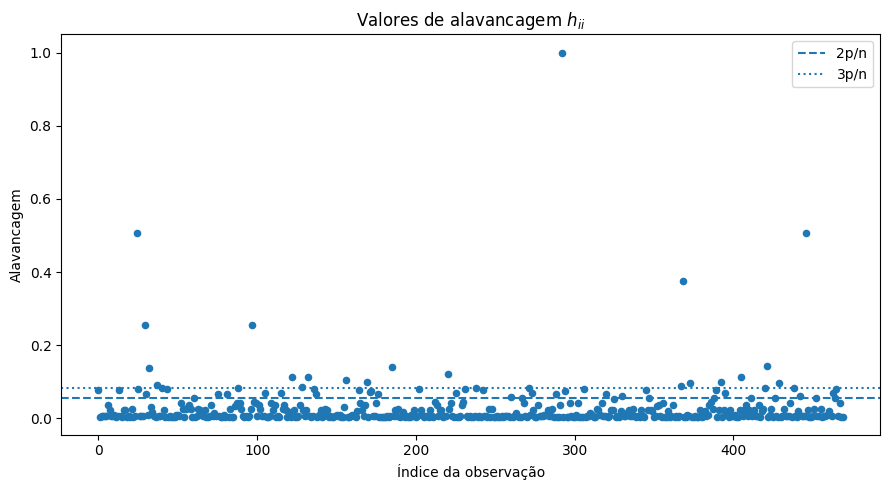

Gráfico salvo em:
outputs\graficos_influencia\grafico_alavancagem.png


In [9]:
# Gráfico da alavancagem h_ii

plt.figure(figsize=(9, 5))

plt.scatter(
    tabela_influencia["indice"],
    tabela_influencia["h_ii"],
    s=20
)

plt.axhline(limiar_h_2p_n, linestyle="--", label="2p/n")
plt.axhline(limiar_h_3p_n, linestyle=":", label="3p/n")

plt.xlabel("Índice da observação")
plt.ylabel("Alavancagem")
plt.title("Valores de alavancagem $h_{ii}$")
plt.legend()
plt.tight_layout()

caminho_grafico_h = PASTA_GRAFICOS / "grafico_alavancagem.png"
plt.savefig(caminho_grafico_h, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico salvo em:")
print(caminho_grafico_h)

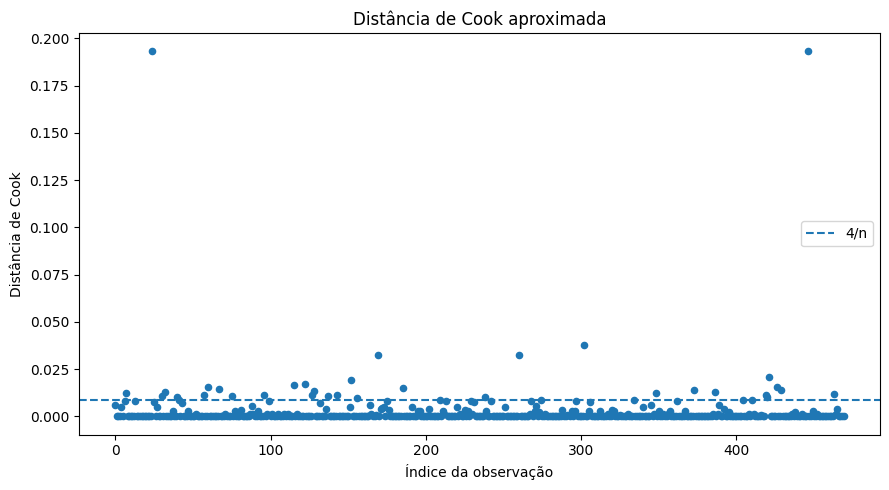

Gráfico salvo em:
outputs\graficos_influencia\grafico_distancia_cook.png


In [10]:
# Gráfico da distância de Cook

plt.figure(figsize=(9, 5))

plt.scatter(
    tabela_influencia["indice"],
    tabela_influencia["distancia_cook"],
    s=20
)

plt.axhline(limiar_cook_4_n, linestyle="--", label="4/n")

plt.xlabel("Índice da observação")
plt.ylabel("Distância de Cook")
plt.title("Distância de Cook aproximada")
plt.legend()
plt.tight_layout()

caminho_grafico_cook = PASTA_GRAFICOS / "grafico_distancia_cook.png"
plt.savefig(caminho_grafico_cook, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico salvo em:")
print(caminho_grafico_cook)

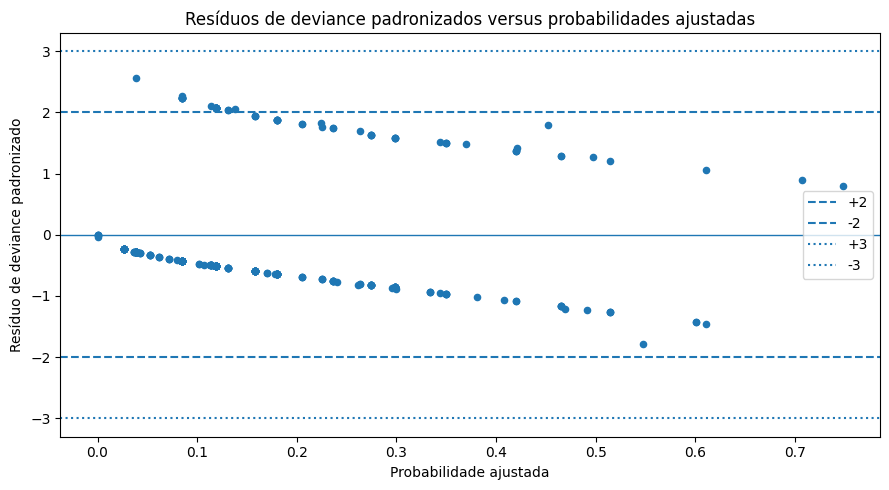

Gráfico salvo em:
outputs\graficos_influencia\grafico_residuos_probabilidades.png


In [11]:
# Gráfico dos resíduos de deviance padronizados versus probabilidades ajustadas

plt.figure(figsize=(9, 5))

plt.scatter(
    tabela_influencia["probabilidade_ajustada"],
    tabela_influencia["residuo_deviance_padronizado"],
    s=20
)

plt.axhline(0, linewidth=1)
plt.axhline(2, linestyle="--", label="+2")
plt.axhline(-2, linestyle="--", label="-2")
plt.axhline(3, linestyle=":", label="+3")
plt.axhline(-3, linestyle=":", label="-3")

plt.xlabel("Probabilidade ajustada")
plt.ylabel("Resíduo de deviance padronizado")
plt.title("Resíduos de deviance padronizados versus probabilidades ajustadas")
plt.legend()
plt.tight_layout()

caminho_grafico_residuos = PASTA_GRAFICOS / "grafico_residuos_probabilidades.png"
plt.savefig(caminho_grafico_residuos, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico salvo em:")
print(caminho_grafico_residuos)

In [12]:
# Salvar tabela principal de influência
tabela_influencia.to_csv(
    CAMINHO_INFLUENCIA,
    index=False,
    encoding="utf-8-sig"
)

print("Tabela de influência salva em:")
print(CAMINHO_INFLUENCIA)

# Salvar DFBETAS, se calculados
if not tabela_dfbetas.empty:
    tabela_dfbetas.to_csv(
        CAMINHO_DFBETAS,
        index=False,
        encoding="utf-8-sig"
    )
    
    print("\nTabela de DFBETAS salva em:")
    print(CAMINHO_DFBETAS)
else:
    print("\nTabela de DFBETAS não foi salva porque não foi calculada.")

Tabela de influência salva em:
outputs\influencia.csv

Tabela de DFBETAS salva em:
outputs\dfbetas.csv


In [13]:
import statsmodels.api as sm
import pandas as pd

resultado_final = sm.load("outputs/modelo_final.pkl")

coeficientes_modelo = pd.DataFrame({
    "variavel": resultado_final.params.index,
    "coeficiente": resultado_final.params.values
})

display(coeficientes_modelo)

,variavel,coeficiente
0,constante,-3.590333
1,"C(diagnostico, Treatment(reference='DGN3'))[T....",-19.567379
2,"C(diagnostico, Treatment(reference='DGN3'))[T....",0.483186
3,"C(diagnostico, Treatment(reference='DGN3'))[T....",0.323904
4,"C(diagnostico, Treatment(reference='DGN3'))[T....",2.057786
5,"C(diagnostico, Treatment(reference='DGN3'))[T....",-19.133847
6,"C(diagnostico, Treatment(reference='DGN3'))[T....",3.399590
7,"C(tamanho_tumor_tnm, Treatment(reference='OC11...",0.381487
8,"C(tamanho_tumor_tnm, Treatment(reference='OC11...",1.204909
9,"C(tamanho_tumor_tnm, Treatment(reference='OC11...",1.759053


In [14]:
import pandas as pd

diagnostico_global = pd.read_csv("outputs/diagnostico_global.csv")
hosmer = pd.read_csv("outputs/hosmer_lemeshow.csv")
residuos = pd.read_csv("outputs/residuos.csv")
influencia = pd.read_csv("outputs/influencia.csv")
dfbetas = pd.read_csv("outputs/dfbetas.csv")

display(diagnostico_global)
display(hosmer)

print("Resumo dos resíduos de deviance padronizados:")
display(residuos["residuo_deviance_padronizado"].describe())

print("Quantidade de resíduos |t_D| > 2:")
print((residuos["residuo_deviance_padronizado"].abs() > 2).sum())

print("Quantidade de resíduos |t_D| > 3:")
print((residuos["residuo_deviance_padronizado"].abs() > 3).sum())

print("Resumo da influência:")
print("h_ii > 2p/n:", influencia["alavancagem_maior_2p_n"].sum())
print("h_ii > 3p/n:", influencia["alavancagem_maior_3p_n"].sum())
print("Cook > 4/n:", influencia["cook_maior_4_n"].sum())
print("|resíduo deviance padronizado| > 2:", influencia["residuo_maior_2"].sum())
print("|resíduo deviance padronizado| > 3:", influencia["residuo_maior_3"].sum())

print("Quantidade de observações com DFBETA acima do limite:")
print(dfbetas["dfbeta_maior_2_raiz_n"].sum())

,medida,valor
0,deviance_modelo_final,351.894284
1,graus_liberdade_deviance,457.000000
2,p_valor_deviance,0.999916
3,estatistica_hosmer_lemeshow,3.736264
4,graus_liberdade_hosmer_lemeshow,6.000000
5,p_valor_hosmer_lemeshow,0.712316
6,numero_grupos_hosmer_lemeshow,8.000000
7,log_verossimilhanca,-175.947142
8,numero_observacoes,470.000000
9,numero_parametros,13.000000


,grupo,n,obitos_observados,obitos_esperados,probabilidade_media,nao_obitos_observados,nao_obitos_esperados,componente_obito,componente_nao_obito
0,"(-0.000999999802, 0.0388]",54,1.0,1.654787,0.030644,53.0,52.345213,0.259094,0.008191
1,"(0.0388, 0.0847]",123,8.0,10.018358,0.081450,115.0,112.981642,0.406630,0.036057
2,"(0.0847, 0.113]",14,1.0,1.555409,0.111101,13.0,12.444591,0.198326,0.024788
3,"(0.113, 0.119]",133,16.0,15.872304,0.119341,117.0,117.127696,0.001027,0.000139
4,"(0.119, 0.13]",8,2.0,1.043596,0.130450,6.0,6.956404,0.876497,0.131492
5,"(0.13, 0.18]",46,10.0,7.752480,0.168532,36.0,38.247520,0.651578,0.132070
6,"(0.18, 0.298]",49,15.0,12.800071,0.261226,34.0,36.199929,0.378099,0.133693
7,"(0.298, 0.748]",43,17.0,19.302997,0.448907,26.0,23.697003,0.274765,0.223817


Resumo dos resíduos de deviance padronizados:


count    470.000000
mean      -0.172445
std        0.866996
min       -1.792323
25%       -0.505485
50%       -0.422010
75%       -0.282865
max        2.561678
Name: residuo_deviance_padronizado, dtype: float64

Quantidade de resíduos |t_D| > 2:
29
Quantidade de resíduos |t_D| > 3:
0
Resumo da influência:
h_ii > 2p/n: 67
h_ii > 3p/n: 22
Cook > 4/n: 39
|resíduo deviance padronizado| > 2: 29
|resíduo deviance padronizado| > 3: 0
Quantidade de observações com DFBETA acima do limite:
127
